In [8]:
import os
import sys
import yaml
import torch

import medmnist
from medmnist import INFO
from torchvision import transforms

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.models import get_model

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

config_path = "../config/config.yaml"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

data_flag = "pathmnist"
info = INFO[data_flag]
DataClass = getattr(medmnist, info["python_class"])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

root_dir = "./datasets"
os.makedirs(root_dir, exist_ok=True)

test_dataset = DataClass(
    split="test",
    transform=transform,
    download=True,
    root=root_dir
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

model = get_model(model_name="resnet18", num_classes=9)

weights_path = "../runs/resnet18/run_20260527_173040/best_model.pth"

model.load_state_dict(torch.load(weights_path, map_location=device))
model = model.to(device)
model.eval()


Using device: cuda
Using downloaded and verified file: ./datasets\pathmnist.npz
-> Initializing Standard Deep Learning Baseline: ResNet-18 (Adapted for 28x28)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

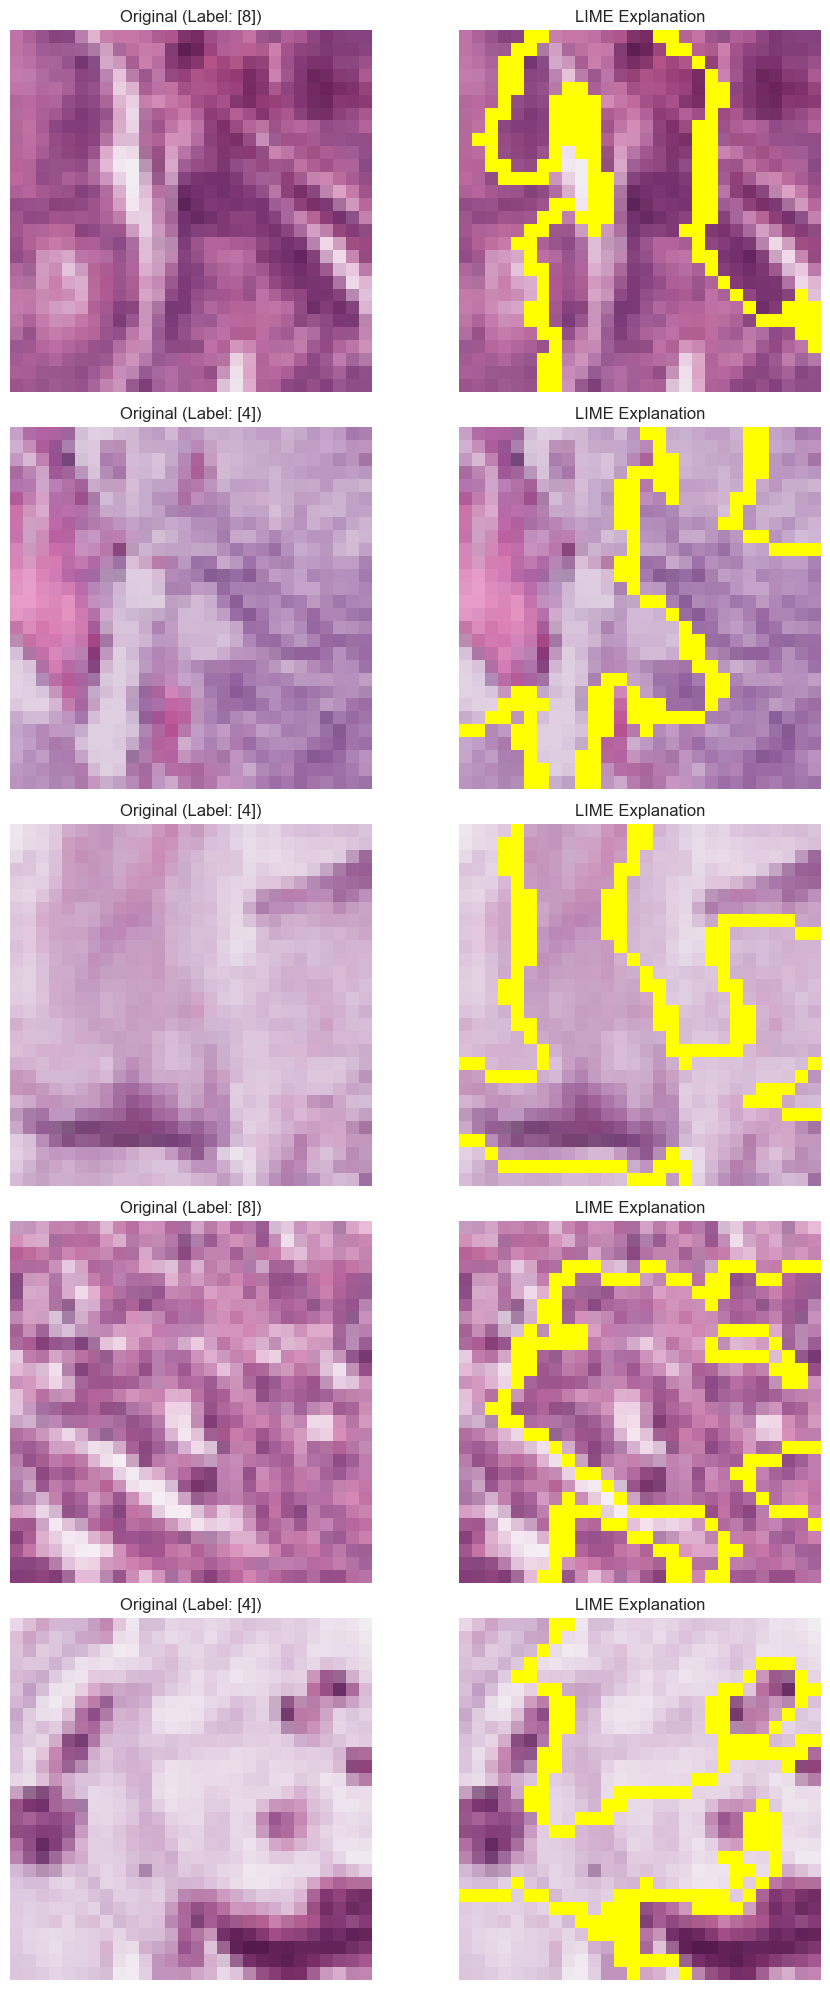

In [25]:
import torch
import random
import matplotlib.pyplot as plt

from torchvision import transforms
from lime import lime_image
from skimage.segmentation import mark_boundaries
from PIL import Image

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# IMPORTANT: transform ONLY for model input
lime_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

from skimage.segmentation import slic

def segmentation_fn(image):
    return slic(
        image,
        n_segments=25,
        compactness=10,
        sigma=1,
        start_label=0
    )

# PREDICTION WRAPPER (FIXED)
class LimePredictor:
    def __init__(self, model, device, transform):
        self.model = model
        self.device = device
        self.transform = transform

    def predict(self, images):
        self.model.eval()

        batch = []

        for img in images:

            # IMPORTANT: LIME gives RGB float [0,1]
            if isinstance(img, np.ndarray):
                img = np.clip(img, 0, 1)
                img = (img * 255).astype(np.uint8)
                img = Image.fromarray(img)

            # apply correct transform (resize + normalize)
            img = self.transform(img)
            batch.append(img)

        batch = torch.stack(batch).to(self.device)

        with torch.no_grad():
            outputs = self.model(batch)
            probs = F.softmax(outputs, dim=1)

        return probs.cpu().numpy()

# INIT LIME
predict_fn = LimePredictor(model, device, lime_transform)
explainer = lime_image.LimeImageExplainer(random_state=42)

n_examples = 5
indices = range(5)

# VISUALIZATION
fig, axes = plt.subplots(n_examples, 2, figsize=(10, n_examples * 4))

for row, idx in enumerate(indices):

    img_tensor, label = test_dataset[idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)

    explanation = explainer.explain_instance(
        img_np,
        predict_fn.predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000,
        segmentation_fn=segmentation_fn
    )

    top_label = explanation.top_labels[0]

    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    overlay = mark_boundaries(temp, mask)

    # ORIGINAL
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Original (Label: {label})")
    axes[row, 0].axis("off")

    # LIME
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title("LIME Explanation")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

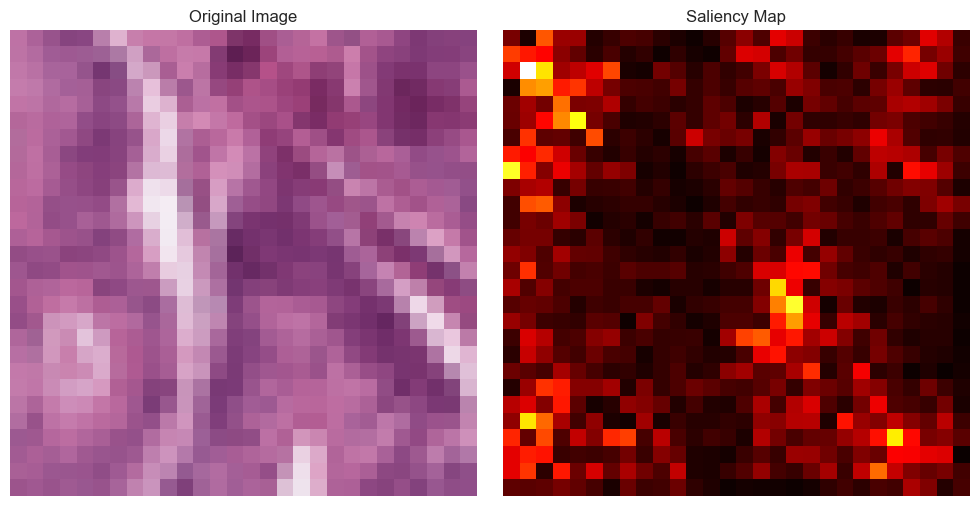

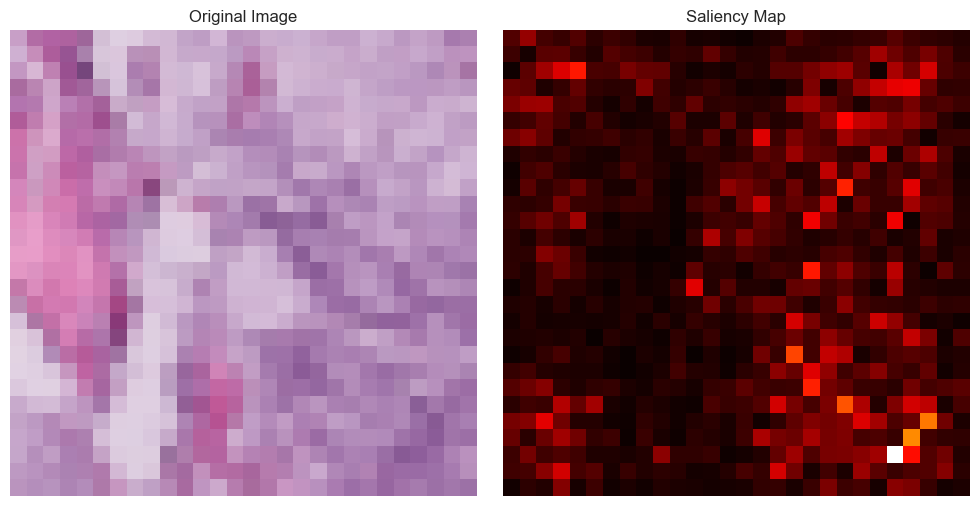

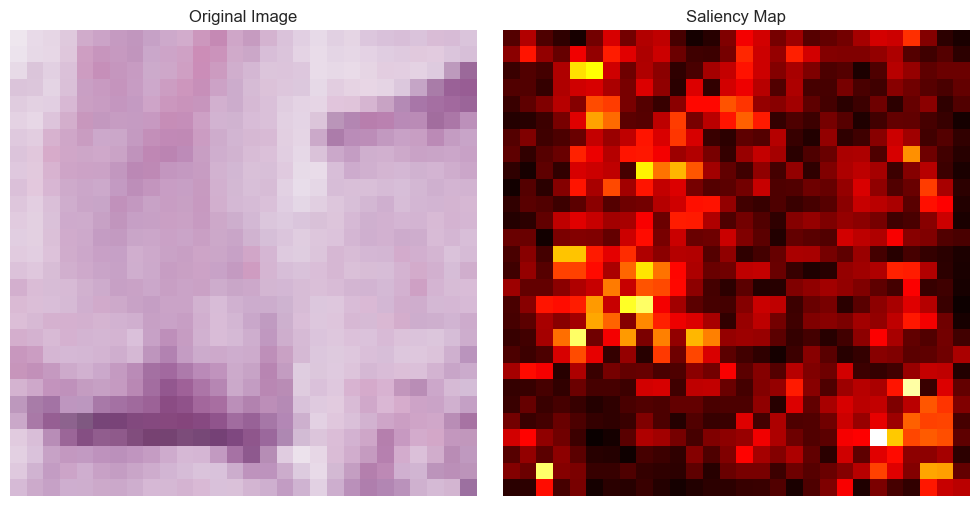

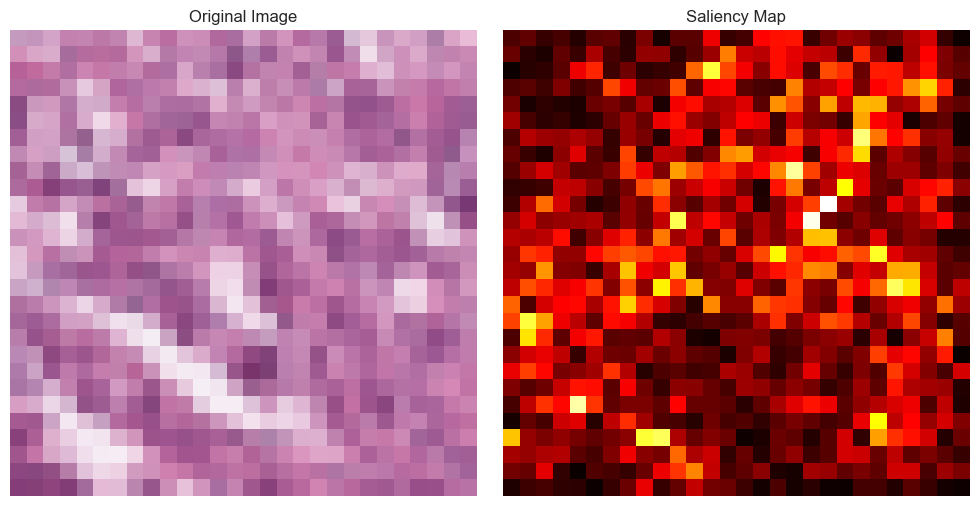

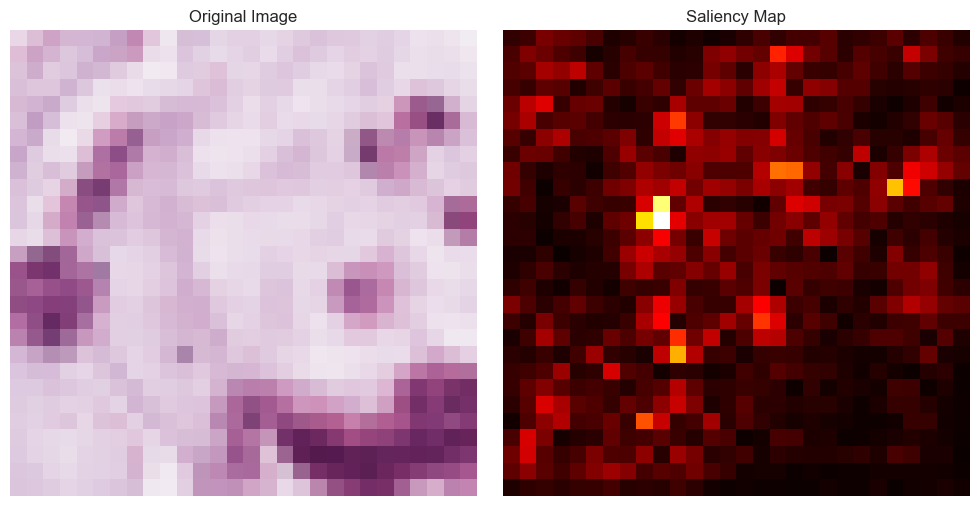

In [16]:
import torch

def compute_saliency_map(model, img_tensor, label_index):
    model.eval()
    device = next(model.parameters()).device

    # Move image to device and enable gradients
    img_tensor = img_tensor.unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    # Forward pass
    output = model(img_tensor)

    # Target class score
    score = output[0, label_index]

    # Backprop
    model.zero_grad()
    score.backward()

    # Compute saliency (absolute gradient)
    saliency = img_tensor.grad.data.abs().squeeze()

    # Collapse RGB → single map
    saliency, _ = torch.max(saliency, dim=0)

    # Normalize safely (avoid divide-by-zero)
    saliency_min = saliency.min()
    saliency_max = saliency.max()
    saliency = (saliency - saliency_min) / (saliency_max - saliency_min + 1e-8)

    # Convert image for display
    img_np = img_tensor.detach().squeeze().cpu().permute(1, 2, 0).numpy()

    # If normalized with 0.5 mean/std → unnormalize
    img_np = (img_np * 0.5 + 0.5).clip(0, 1)

    # Plot
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    axs[1].imshow(saliency.cpu().numpy(), cmap="hot")
    axs[1].set_title("Saliency Map")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()
    

for i in range(5):
    img, label = test_dataset[i]

    compute_saliency_map(
        model=model,
        img_tensor=img,
        label_index=label.item() if torch.is_tensor(label) else label
    )

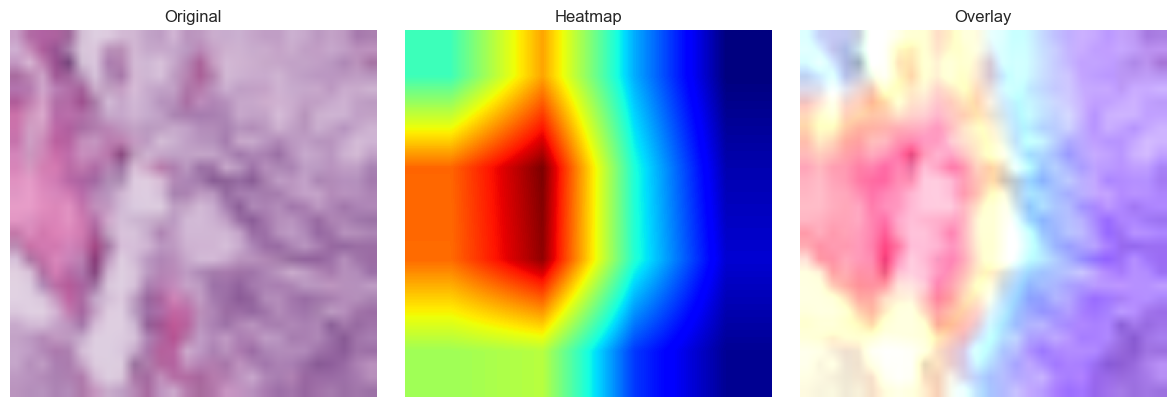

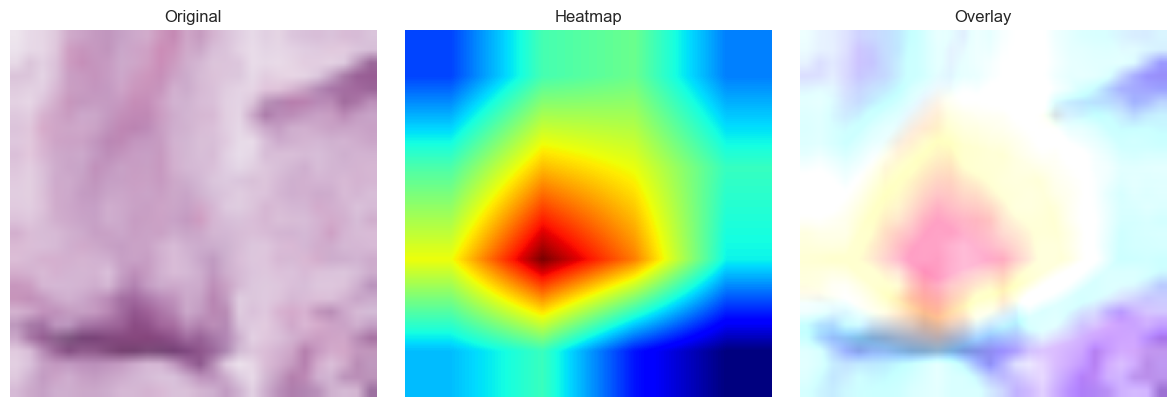

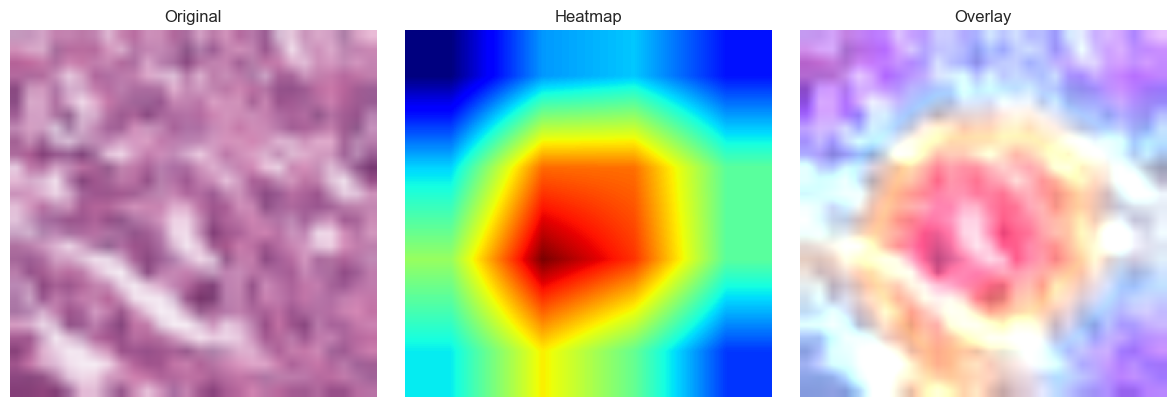

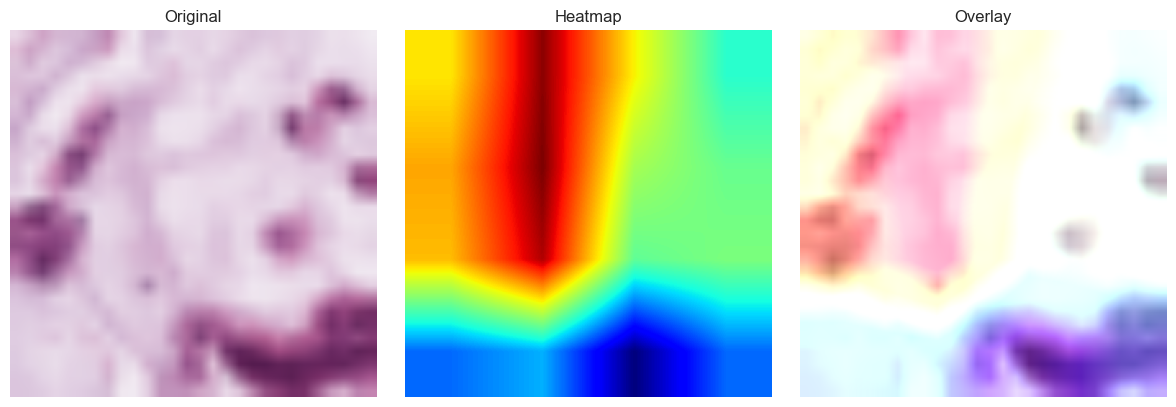

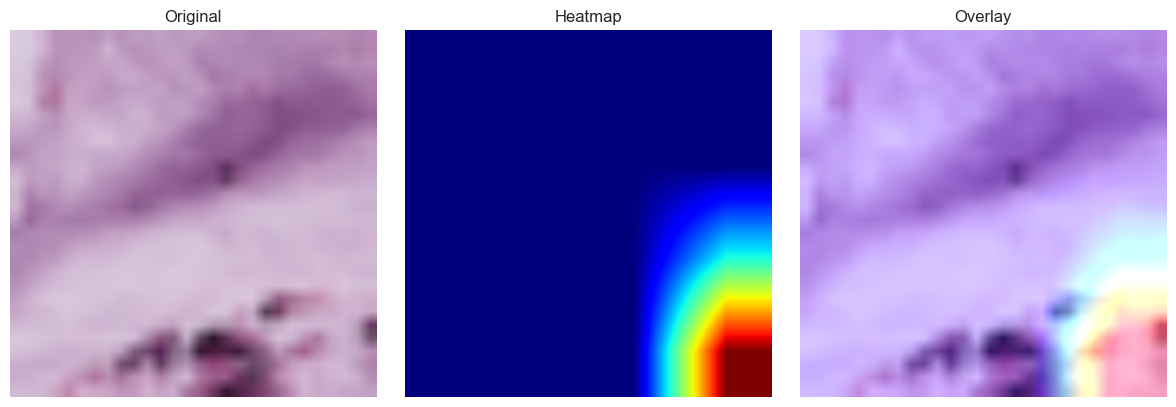

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2


# GRAD-CAM CLASS
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x, class_idx=None):
        self.model.eval()

        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        weights = torch.mean(self.gradients, dim=(2, 3))

        cam = torch.zeros(self.activations.shape[2:], device=x.device)

        for i, w in enumerate(weights[0]):
            cam += w * self.activations[0, i]

        cam = F.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        cam = cam.detach().cpu().numpy()
        cam = cv2.resize(cam, (224, 224))

        return cam


# VISUALIZATION
def show_gradcam(img_tensor, cam):

    # resize image to match cam (IMPORTANT FIX)
    img = img_tensor.permute(1, 2, 0).cpu().numpy()

    # unnormalize (your training: 0.5 mean/std)
    img = (img * 0.5 + 0.5).clip(0, 1)

    # resize image to 224x224 to match CAM
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap / 255.0

    overlay = heatmap * 0.4 + img
    overlay = np.clip(overlay, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(cam, cmap="jet")
    ax[1].set_title("Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


# SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

target_layer = model.layer4[-1].conv2
gradcam = GradCAM(model, target_layer)

# RUN EXAMPLES
for i in range(1, 6):

    img_tensor, label = test_dataset[i]

    img_tensor = img_tensor.float().to(device)
    img_tensor = img_tensor.unsqueeze(0)

    cam = gradcam(img_tensor)

    show_gradcam(img_tensor.squeeze(0).cpu(), cam)
